# Testing the ```MandyocScen``` Class with basic examples

The `MandyocScen` is a object that contains the params, metadata and the whole data of a SCENARIO:

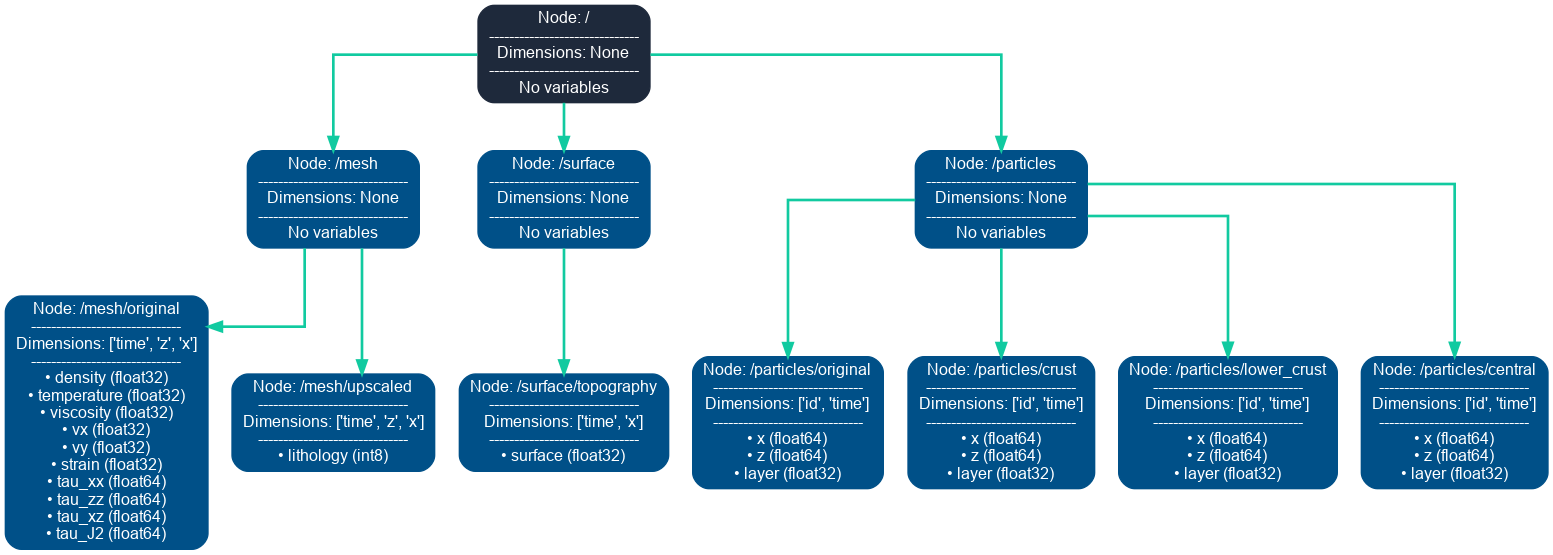

This example requires all the netcdf files for a simulation.
You can create it for your scenario with the Julia Scripts in the postprocessing folder (`meshes2netcdf.jl` and `particles2netcdf.jl`). An example of slurm job is inside the example folder.

In [1]:
import matplotlib.pyplot as plt
import numpy as np

# Loading the MandyocScen class from the scenClasses module
from tapioca import MandyocScen as MS

## 1. Creating the `MandyocScen` Object

We can load many data with the creation of the scenario object. It is recommend to load everything in this moment, but it is also possible to load after the creation.

In [2]:
#Basic usage:

#Load a scenario with the variables of interest
scen = MS('continental_rift/', name='Continental Rift',
        variables=['density','temperature','viscosity','velocity','strain'],
        xlimits=[50e3,1150e3], zlimits=[-300e3,0e3], tlimits=[0,10],
        load_lithology=True, load_surface=True, load_particles=True,
        verbose=True)

#Recommended: correct the Z coordinate to match 0 at the air-surface interface
scen.correctZcoord()

display(scen.DTree)
print(f'DataTree size: {scen.DTree.nbytes/(1024**2):.3f} MB')

Scenario at: continental_rift
Scenario name: Continental Rift
Params - Ok
x limits: [50000.0, 1150000.0]
z limits: [-300000.0, 0.0]
time limits: [0, 10]


/home/jobueno/opt/tapioca/src/tapioca/scenClasses.py:187: FutureWarning: In a future version of xarray the default value for compat will change from compat='no_conflicts' to compat='override'. This is likely to lead to different results when combining overlapping variables with the same name. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set compat explicitly.
  self.DTree['/mesh/original'] = xr.merge(standard_datasets, join='outer')


Variables loaded: density temperature viscosity velocity strain
Lithology loaded
Surface loaded
Air particles filtered [6]
Particles [particles_trajectories.nc] loaded
Z coordinate corrected by + 40000.0 m
New z limits: [-260000.0, 40000.0]


<xarray.DataTree>
Group: /
│   Attributes:
│       name:     Continental Rift
│       xlimits:  [50000.0, 1150000.0]
│       zlimits:  [-300000.0, 0.0]
│       tlimits:  [0, 10]
├── Group: /mesh
│   ├── Group: /mesh/original
│   │       Dimensions:      (time: 21, z: 31, x: 111)
│   │       Coordinates:
│   │         * time         (time) float64 168B 0.0 0.5 1.0 1.5 ... 8.499 8.999 9.499 9.999
│   │           step         (time) int32 84B dask.array<chunksize=(21,), meta=np.ndarray>
│   │         * z            (z) float32 124B -2.6e+05 -2.5e+05 -2.4e+05 ... 3e+04 4e+04
│   │         * x            (x) float32 444B 5e+04 6e+04 7e+04 ... 1.14e+06 1.15e+06
│   │       Data variables:
│   │           density      (time, z, x) float32 289kB dask.array<chunksize=(21, 31, 111), meta=np.ndarray>
│   │           temperature  (time, z, x) float32 289kB dask.array<chunksize=(21, 31, 111), meta=np.ndarray>
│   │           viscosity    (time, z, x) float64 578kB dask.array<chunksize=(21, 31, 111), meta=np.ndarray>
│   │           vx           (time, z, x) float64 578kB dask.array<chunksize=(21, 31, 111), meta=np.ndarray>
│   │           vz           (time, z, x) float64 578kB dask.array<chunksize=(21, 31, 111), meta=np.ndarray>
│   │           strain       (time, z, x) float64 578kB dask.array<chunksize=(21, 31, 111), meta=np.ndarray>
│   └── Group: /mesh/upscaled
│           Dimensions:    (time: 21, z: 151, x: 551)
│           Coordinates:
│             * time       (time) float64 168B 0.0 0.5 1.0 1.5 ... 8.499 8.999 9.499 9.999
│               step       (time) int32 84B dask.array<chunksize=(21,), meta=np.ndarray>
│             * z          (z) float32 604B -2.6e+05 -2.58e+05 -2.56e+05 ... 3.8e+04 4e+04
│             * x          (x) float32 2kB 5e+04 5.2e+04 5.4e+04 ... 1.148e+06 1.15e+06
│           Data variables:
│               lithology  (time, z, x) int8 2MB dask.array<chunksize=(21, 151, 551), meta=np.ndarray>
├── Group: /surface
│   └── Group: /surface/topography
│           Dimensions:  (time: 21, x: 5501)
│           Coordinates:
│             * time     (time) float64 168B 0.0 0.5 1.0 1.5 2.0 ... 8.499 8.999 9.499 9.999
│               step     (time) int32 84B dask.array<chunksize=(21,), meta=np.ndarray>
│             * x        (x) float32 22kB 5e+04 5.02e+04 5.04e+04 ... 1.15e+06 1.15e+06
│           Data variables:
│               surface  (time, x) float32 462kB dask.array<chunksize=(21, 5501), meta=np.ndarray>
└── Group: /particles
    └── Group: /particles/original
            Dimensions:    (time: 21, id: 18000)
            Coordinates:
              * time       (time) float64 168B 0.0 0.5 1.0 1.5 ... 8.499 8.999 9.499 9.999
                step       (time) int32 84B dask.array<chunksize=(21,), meta=np.ndarray>
              * id         (id) int32 72kB 10012 10015 10033 ... 3065635 3065636 3065651
                x          (time, id) float32 2MB dask.array<chunksize=(21, 18000), meta=np.ndarray>
                z          (time, id) float32 2MB dask.array<chunksize=(21, 18000), meta=np.ndarray>
            Data variables:
                lithology  (time, id) float32 2MB dask.array<chunksize=(21, 18000), meta=np.ndarray>
            Attributes:
                Conventions:         CF-1.8
                featureType:         trajectory
                description:         particle trajectories
                reference_timestep:  0

DataTree size: 9.283 MB


In [3]:
print(type(scen.params))
display(scen.params)

<class 'dict'>


{'nx': '121',
 'nz': '31',
 'lx': '1200000.0',
 'lz': '300000.0',
 'multigrid': '1',
 'solver': 'direct',
 'denok': '1.0e-15',
 'particles_per_element': '64',
 'particles_perturb_factor': '0.7',
 'particles_to_export': '5',
 'rtol': '1.0e-7',
 'rk4': 'Euler',
 'xi_min': '1.0e-7',
 'random_initial_strain': '0.3',
 'pressure_const': '-1.0',
 'initial_dynamic_range': 'True',
 'periodic_boundary': 'False',
 'high_kappa_in_asthenosphere': 'False',
 'k_fluvial': '2.0e-7',
 'm_fluvial': '1.0',
 'sea_level': '0.0',
 'basal_heat': '0.0',
 'sp_surface_tracking': 'True',
 'surface_particles_per_element': '50',
 'sp_surface_processes': 'False',
 'sp_d_c': '1.0',
 'plot_sediment': 'False',
 'a2l': 'True',
 'free_surface_stab': 'True',
 'theta_fssa': '0.5',
 'step_max': '200',
 'time_max': '10.0e6',
 'dt_max': '50.0e3',
 'step_print': '10',
 'sub_division_time_step': '0.5',
 'initial_print_step': '0',
 'initial_print_max_time': '1.0e6',
 'viscosity_reference': '1.0e26',
 'viscosity_max': '1.0e25',
 

A full guide of DataTree manipulation can be find at: [https://docs.xarray.dev/en/latest/user-guide/hierarchical-data.html]

In [4]:
print('A brief view of our DataTree:')
for node in scen.DTree.subtree:
    print(node.path)

A brief view of our DataTree:
/
/mesh
/surface
/particles
/mesh/original
/mesh/upscaled
/surface/topography
/particles/original


## Executing Post-processing Operations

Postprocessings may be executed through the ```scenPostProcessing``` class acessing the DataTree:

In [5]:
# Calculating the stress tensor field
scen.DTree.postproc.DeviatoricStressTensor()
display(scen.DTree.mesh['original'].ds)  # ds -> DataSet View

dev stress is given in MPa (1000000.0)


<xarray.DatasetView> Size: 5MB
Dimensions:      (time: 21, z: 31, x: 111)
Coordinates:
  * time         (time) float64 168B 0.0 0.5 1.0 1.5 ... 8.499 8.999 9.499 9.999
    step         (time) int32 84B dask.array<chunksize=(21,), meta=np.ndarray>
  * z            (z) float32 124B -2.6e+05 -2.5e+05 -2.4e+05 ... 3e+04 4e+04
  * x            (x) float32 444B 5e+04 6e+04 7e+04 ... 1.14e+06 1.15e+06
Data variables:
    density      (time, z, x) float32 289kB dask.array<chunksize=(21, 31, 111), meta=np.ndarray>
    temperature  (time, z, x) float32 289kB dask.array<chunksize=(21, 31, 111), meta=np.ndarray>
    viscosity    (time, z, x) float64 578kB dask.array<chunksize=(21, 31, 111), meta=np.ndarray>
    vx           (time, z, x) float64 578kB dask.array<chunksize=(21, 31, 111), meta=np.ndarray>
    vz           (time, z, x) float64 578kB dask.array<chunksize=(21, 31, 111), meta=np.ndarray>
    strain       (time, z, x) float64 578kB dask.array<chunksize=(21, 31, 111), meta=np.ndarray>
    tau_xx       (time, z, x) float64 578kB dask.array<chunksize=(21, 31, 111), meta=np.ndarray>
    tau_zz       (time, z, x) float64 578kB dask.array<chunksize=(21, 31, 111), meta=np.ndarray>
    tau_xz       (time, z, x) float64 578kB dask.array<chunksize=(21, 31, 111), meta=np.ndarray>
    tau_J2       (time, z, x) float64 578kB dask.array<chunksize=(21, 31, 111), meta=np.ndarray>

### Scenario manipulation and plotting

In this example, the variable `mesh`represents all fields in ~5 Myr 

In [6]:
# selecting all data at 5 Myr and getting the original mesh dataset
CRTsel = scen.DTree.sel(time=5,method='nearest')
mesh = CRTsel.mesh['original'].ds # ds -> DataSet View

(-260000.0, 40000.0)

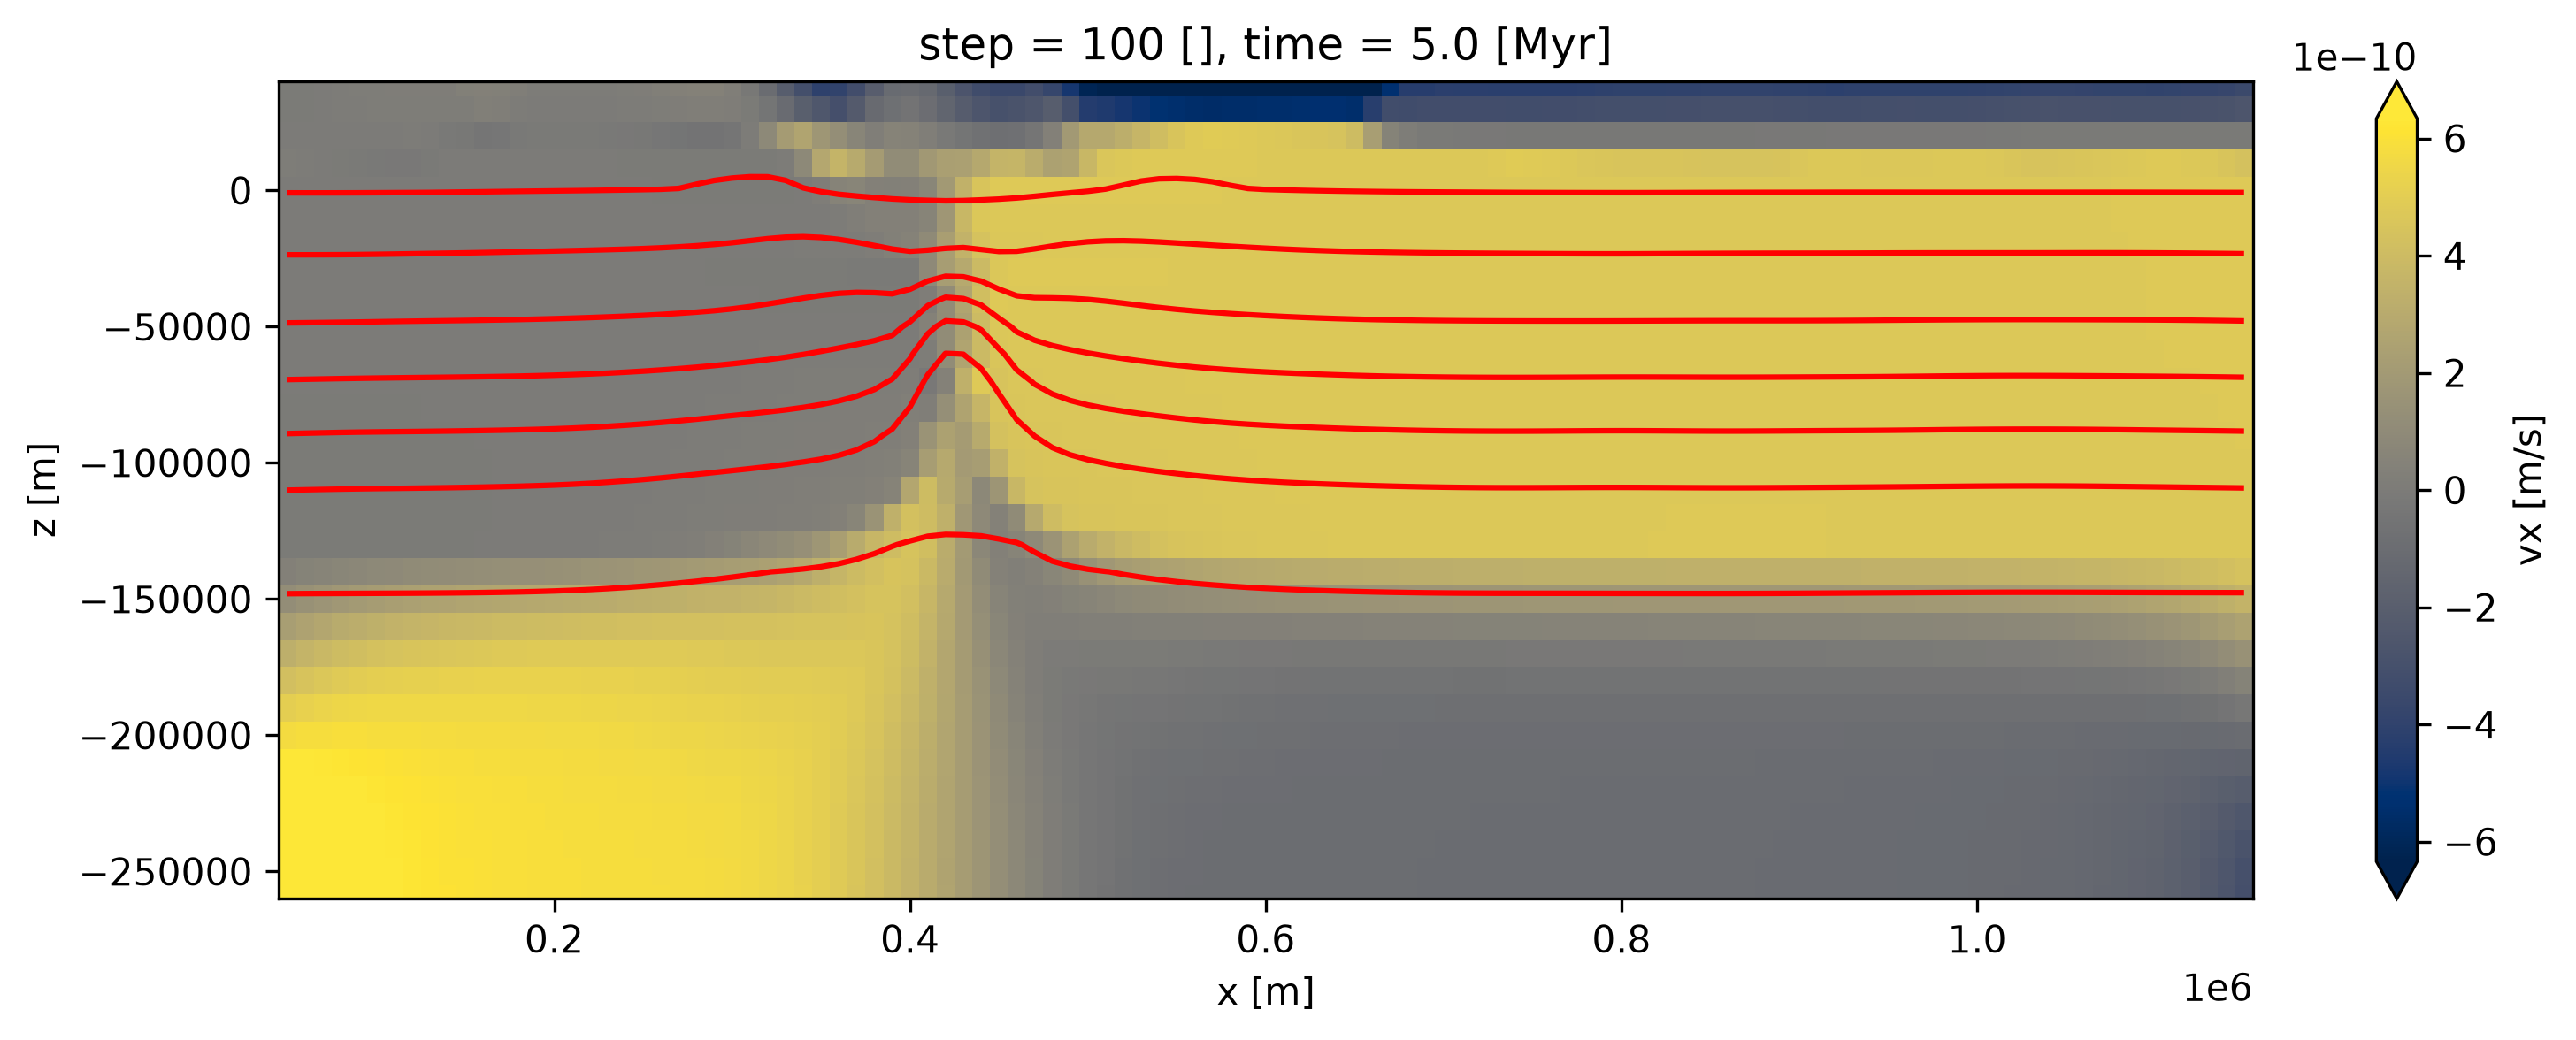

In [7]:
# plotting the velocity field and temperature contours through the xarray methods
factor = 100 * 365.25 * 24 * 60 * 60 # m/s to cm/y

plt.figure(figsize=(12,4), dpi=300)
mesh['vx'].plot.imshow(x='x',y='z', cmap='cividis', vmin=-2/factor, vmax=2/factor) # convert cm/yr to m/s
mesh['temperature'].plot.contour(x='x',y='z',colors='red',levels=np.linspace(100,1300,7))
plt.ylim(-260e3,40e3)

(-260000.0, 40000.0)

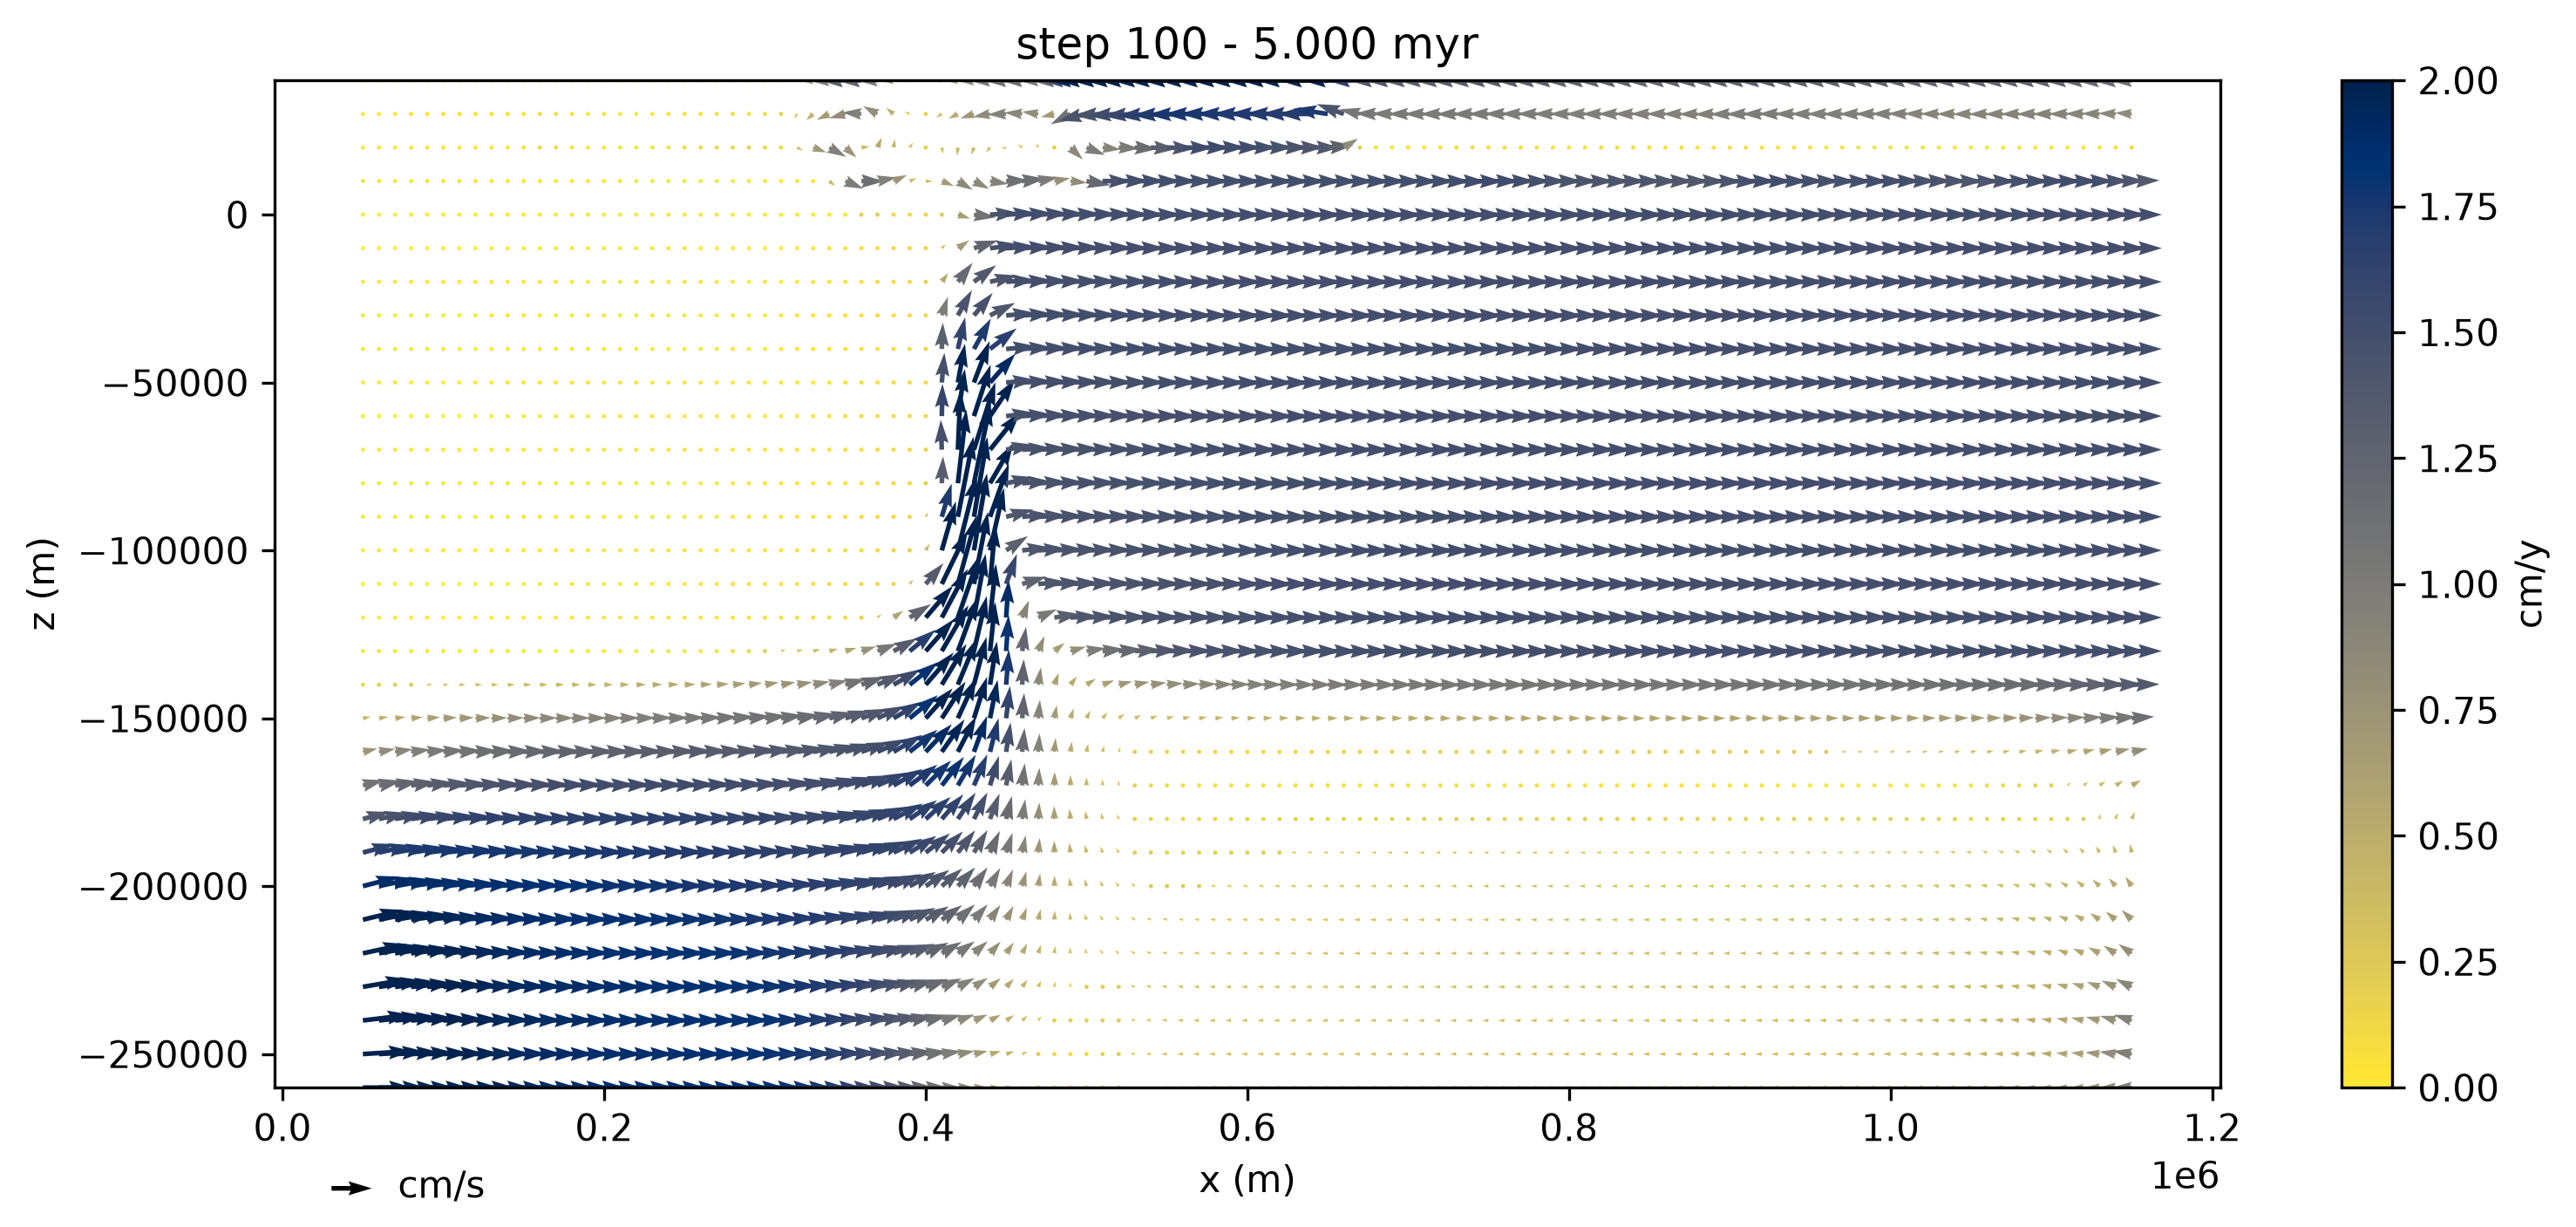

In [8]:
# We also can plot the velocity field with a quiver plot

vx_t = mesh['vx'] * factor
vz_t = mesh['vz'] * factor
v_mag = np.sqrt(vx_t**2+vz_t**2)

fig, ax = plt.subplots(figsize=(12,5),dpi=300)
qplot = ax.quiver(vx_t.x, vx_t.z, vx_t.values, vz_t.values, v_mag, cmap='cividis_r', clim=(0,2))

qkey = ax.quiverkey(qplot, 0.05, -0.1, 2, 'cm/s',labelpos='E',coordinates='axes')
plt.colorbar(qplot,label='cm/y')
plt.xlabel('x (m)')
plt.ylabel('z (m)')
plt.title(f'step {v_mag.step.values} - {v_mag.time.values:.3f} myr')
plt.ylim(-260e3,40e3)

/home/jobueno/miniconda3/envs/tapioca/lib/python3.14/site-packages/dask/_task_spec.py:768: RuntimeWarning: divide by zero encountered in log10
  return self.func(*new_argspec)


(-260000.0, 40000.0)

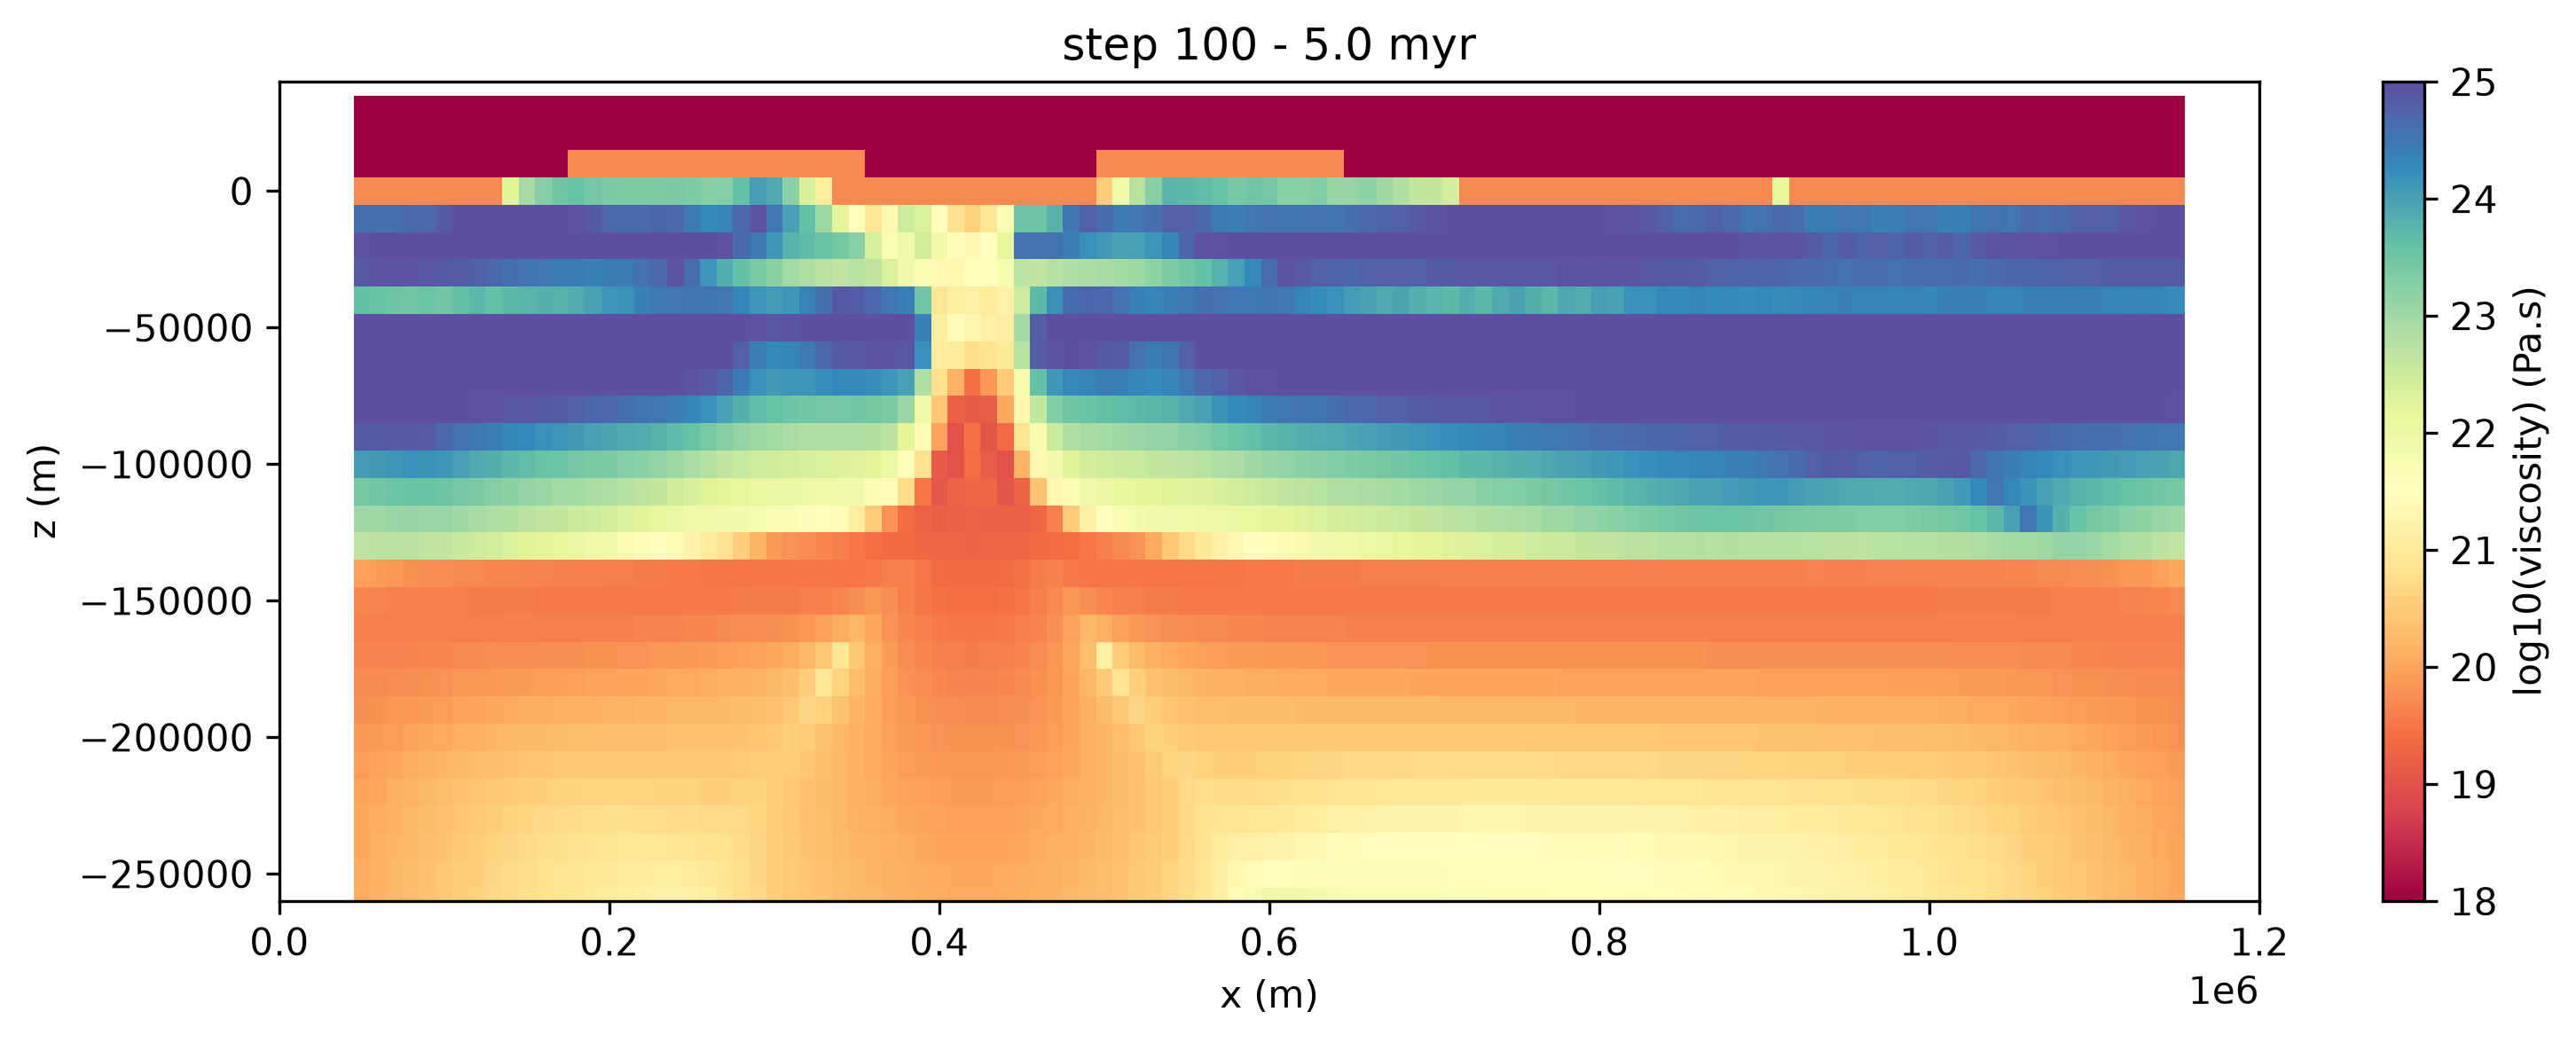

In [9]:
# plotting the viscosity field through the numpy and matplotlib methods 

visc = mesh['viscosity'] # selecting the viscosity field as an xarray DataArray

plt.figure(figsize=(12,4),dpi=300)
plt.pcolormesh(visc.x,visc.z, np.log10(visc), cmap='Spectral')
plt.title(f'step {visc.step.values} - {visc.time.values} myr')
plt.xlabel('x (m)')
plt.ylabel('z (m)')
plt.colorbar(label='log10(viscosity) (Pa.s)')
plt.xlim(0,1200e3); plt.ylim(-260e3,40e3)

Note that the white space in the boundaries occurs due the initial filter for x limits, when we created the class

# Surface
The only surface in this moment is the topography, with a high resolution in x (2D Scenarios). 

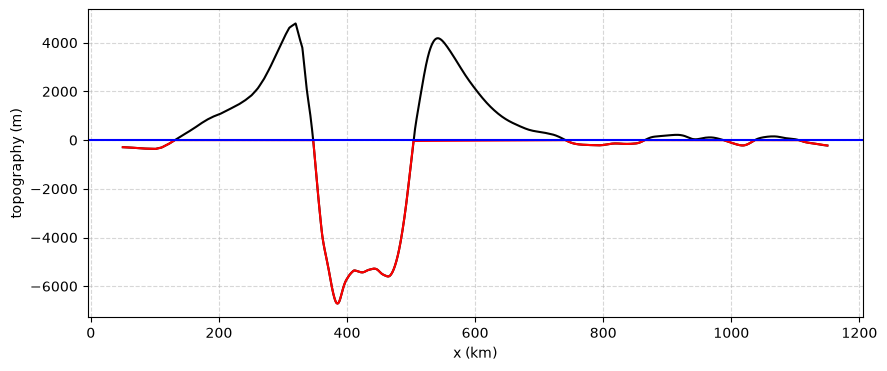

In [10]:
# The surface is already corrected with the previous correctZ function

topo = CRTsel['surface'].topography
topo_neg = topo.surface[(topo.surface.values < 0)] # only negative values

plt.figure(figsize=(10,4))
plt.plot(topo.x/1e3, topo.surface.values, color='black')
plt.plot(topo_neg.x/1e3, topo_neg.values, color='red')
plt.axhline(0,color='blue')
plt.xlabel('x (km)')
plt.ylabel('topography (m)')
plt.grid(ls='--',alpha=0.5)

## Particles manipulation

Particles (Lagrangian markers) have the dimensions `(id,time)`, and `x`,`z`, and other properties are variables. 

In [11]:
particles = CRTsel.particles['original'].ds # selecting the original particles dataset as an xarray DataSet
print(f'Number of particles: {int(particles.id.count())}')
display(particles)

Number of particles: 18000


<xarray.DatasetView> Size: 288kB
Dimensions:    (id: 18000)
Coordinates:
  * id         (id) int32 72kB 10012 10015 10033 ... 3065635 3065636 3065651
    x          (id) float32 72kB dask.array<chunksize=(18000,), meta=np.ndarray>
    z          (id) float32 72kB dask.array<chunksize=(18000,), meta=np.ndarray>
    step       int32 4B dask.array<chunksize=(), meta=np.ndarray>
    time       float64 8B 5.0
Data variables:
    lithology  (id) float32 72kB dask.array<chunksize=(18000,), meta=np.ndarray>
Attributes:
    Conventions:         CF-1.8
    featureType:         trajectory
    description:         particle trajectories
    reference_timestep:  0

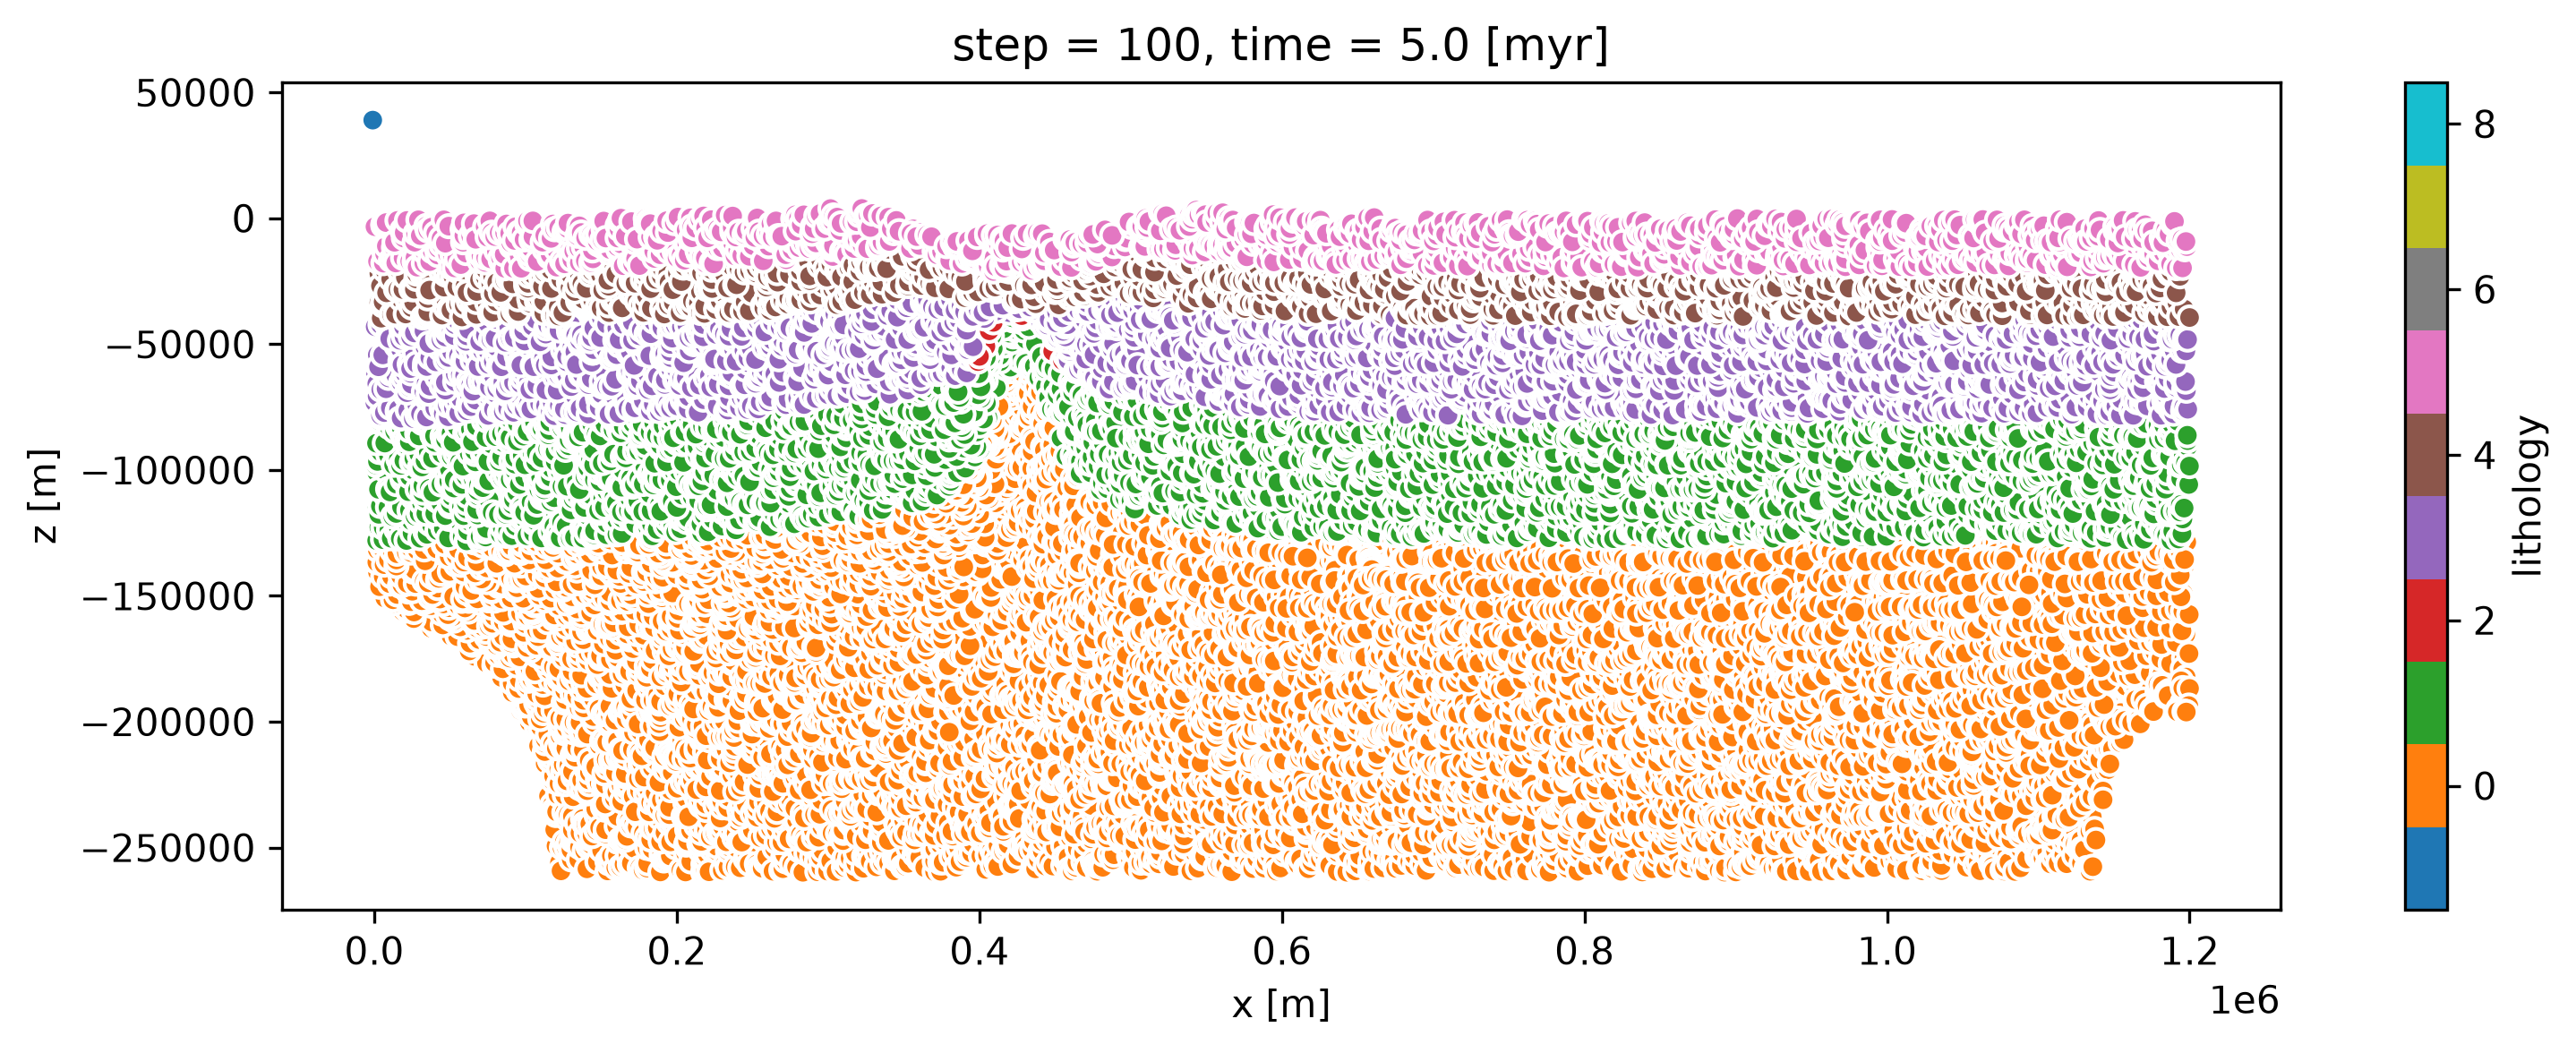

In [12]:
# plotting the particle positions colored by their layer index through the xarray methods
plt.figure(figsize=(12,4),dpi=300)
particles.plot.scatter(x='x',y='z',hue='lithology',cmap='tab10',vmin=-1.5,vmax=8.5)

Note that in this scenario the `id=2` represents a weak seed within the lithospheric mantle, which splits it in 2 lithologies (1 and 3)

In [13]:
scen.DTree.particles.original.ds

<xarray.DatasetView> Size: 5MB
Dimensions:    (time: 21, id: 18000)
Coordinates:
  * time       (time) float64 168B 0.0 0.5 1.0 1.5 ... 8.499 8.999 9.499 9.999
    step       (time) int32 84B dask.array<chunksize=(21,), meta=np.ndarray>
  * id         (id) int32 72kB 10012 10015 10033 ... 3065635 3065636 3065651
    x          (time, id) float32 2MB dask.array<chunksize=(21, 18000), meta=np.ndarray>
    z          (time, id) float32 2MB dask.array<chunksize=(21, 18000), meta=np.ndarray>
Data variables:
    lithology  (time, id) float32 2MB dask.array<chunksize=(21, 18000), meta=np.ndarray>
Attributes:
    Conventions:         CF-1.8
    featureType:         trajectory
    description:         particle trajectories
    reference_timestep:  0

In [14]:
# selecting particles by layer index (e.g., layers 2 and 3 for the crust) and creating a new selection named 'crust'
scen.selectParticles_bylithology([4,5],
                                 selected_name='original', selection_name='crust')


crust_particles = scen.DTree.particles['crust'].ds
print(f'Crust particles: {int(crust_particles.id.count())}')
display(scen.DTree)


Selected particles: original
Selection at: crust
Crust particles: 2400


<xarray.DataTree>
Group: /
│   Attributes:
│       name:     Continental Rift
│       xlimits:  [50000.0, 1150000.0]
│       zlimits:  [-300000.0, 0.0]
│       tlimits:  [0, 10]
├── Group: /mesh
│   ├── Group: /mesh/original
│   │       Dimensions:      (time: 21, z: 31, x: 111)
│   │       Coordinates:
│   │         * time         (time) float64 168B 0.0 0.5 1.0 1.5 ... 8.499 8.999 9.499 9.999
│   │           step         (time) int32 84B dask.array<chunksize=(21,), meta=np.ndarray>
│   │         * z            (z) float32 124B -2.6e+05 -2.5e+05 -2.4e+05 ... 3e+04 4e+04
│   │         * x            (x) float32 444B 5e+04 6e+04 7e+04 ... 1.14e+06 1.15e+06
│   │       Data variables:
│   │           density      (time, z, x) float32 289kB dask.array<chunksize=(21, 31, 111), meta=np.ndarray>
│   │           temperature  (time, z, x) float32 289kB dask.array<chunksize=(21, 31, 111), meta=np.ndarray>
│   │           viscosity    (time, z, x) float64 578kB dask.array<chunksize=(21, 31, 111), meta=np.ndarray>
│   │           vx           (time, z, x) float64 578kB dask.array<chunksize=(21, 31, 111), meta=np.ndarray>
│   │           vz           (time, z, x) float64 578kB dask.array<chunksize=(21, 31, 111), meta=np.ndarray>
│   │           strain       (time, z, x) float64 578kB dask.array<chunksize=(21, 31, 111), meta=np.ndarray>
│   │           tau_xx       (time, z, x) float64 578kB dask.array<chunksize=(21, 31, 111), meta=np.ndarray>
│   │           tau_zz       (time, z, x) float64 578kB dask.array<chunksize=(21, 31, 111), meta=np.ndarray>
│   │           tau_xz       (time, z, x) float64 578kB dask.array<chunksize=(21, 31, 111), meta=np.ndarray>
│   │           tau_J2       (time, z, x) float64 578kB dask.array<chunksize=(21, 31, 111), meta=np.ndarray>
│   └── Group: /mesh/upscaled
│           Dimensions:    (time: 21, z: 151, x: 551)
│           Coordinates:
│             * time       (time) float64 168B 0.0 0.5 1.0 1.5 ... 8.499 8.999 9.499 9.999
│               step       (time) int32 84B dask.array<chunksize=(21,), meta=np.ndarray>
│             * z          (z) float32 604B -2.6e+05 -2.58e+05 -2.56e+05 ... 3.8e+04 4e+04
│             * x          (x) float32 2kB 5e+04 5.2e+04 5.4e+04 ... 1.148e+06 1.15e+06
│           Data variables:
│               lithology  (time, z, x) int8 2MB dask.array<chunksize=(21, 151, 551), meta=np.ndarray>
├── Group: /surface
│   └── Group: /surface/topography
│           Dimensions:  (time: 21, x: 5501)
│           Coordinates:
│             * time     (time) float64 168B 0.0 0.5 1.0 1.5 2.0 ... 8.499 8.999 9.499 9.999
│               step     (time) int32 84B dask.array<chunksize=(21,), meta=np.ndarray>
│             * x        (x) float32 22kB 5e+04 5.02e+04 5.04e+04 ... 1.15e+06 1.15e+06
│           Data variables:
│               surface  (time, x) float32 462kB dask.array<chunksize=(21, 5501), meta=np.ndarray>
└── Group: /particles
    ├── Group: /particles/original
    │       Dimensions:    (time: 21, id: 18000)
    │       Coordinates:
    │         * time       (time) float64 168B 0.0 0.5 1.0 1.5 ... 8.499 8.999 9.499 9.999
    │           step       (time) int32 84B dask.array<chunksize=(21,), meta=np.ndarray>
    │         * id         (id) int32 72kB 10012 10015 10033 ... 3065635 3065636 3065651
    │           x          (time, id) float32 2MB dask.array<chunksize=(21, 18000), meta=np.ndarray>
    │           z          (time, id) float32 2MB dask.array<chunksize=(21, 18000), meta=np.ndarray>
    │       Data variables:
    │           lithology  (time, id) float32 2MB dask.array<chunksize=(21, 18000), meta=np.ndarray>
    │       Attributes:
    │           Conventions:         CF-1.8
    │           featureType:         trajectory
    │           description:         particle trajectories
    │           reference_timestep:  0
    └── Group: /particles/crust
            Dimensions:    (time: 21, id: 2400)
            Coordinates:
              * time       (time) float64 168B 0.

In [15]:
# selecting particles by layer and creating a new selection from 'crust' named 'lower_crust'
scen.selectParticles_bylithology([4],
                                selected_name='crust', selection_name='lower_crust')
display(scen.DTree)

Selected particles: crust
Selection at: lower_crust


<xarray.DataTree>
Group: /
│   Attributes:
│       name:     Continental Rift
│       xlimits:  [50000.0, 1150000.0]
│       zlimits:  [-300000.0, 0.0]
│       tlimits:  [0, 10]
├── Group: /mesh
│   ├── Group: /mesh/original
│   │       Dimensions:      (time: 21, z: 31, x: 111)
│   │       Coordinates:
│   │         * time         (time) float64 168B 0.0 0.5 1.0 1.5 ... 8.499 8.999 9.499 9.999
│   │           step         (time) int32 84B dask.array<chunksize=(21,), meta=np.ndarray>
│   │         * z            (z) float32 124B -2.6e+05 -2.5e+05 -2.4e+05 ... 3e+04 4e+04
│   │         * x            (x) float32 444B 5e+04 6e+04 7e+04 ... 1.14e+06 1.15e+06
│   │       Data variables:
│   │           density      (time, z, x) float32 289kB dask.array<chunksize=(21, 31, 111), meta=np.ndarray>
│   │           temperature  (time, z, x) float32 289kB dask.array<chunksize=(21, 31, 111), meta=np.ndarray>
│   │           viscosity    (time, z, x) float64 578kB dask.array<chunksize=(21, 31, 111), meta=np.ndarray>
│   │           vx           (time, z, x) float64 578kB dask.array<chunksize=(21, 31, 111), meta=np.ndarray>
│   │           vz           (time, z, x) float64 578kB dask.array<chunksize=(21, 31, 111), meta=np.ndarray>
│   │           strain       (time, z, x) float64 578kB dask.array<chunksize=(21, 31, 111), meta=np.ndarray>
│   │           tau_xx       (time, z, x) float64 578kB dask.array<chunksize=(21, 31, 111), meta=np.ndarray>
│   │           tau_zz       (time, z, x) float64 578kB dask.array<chunksize=(21, 31, 111), meta=np.ndarray>
│   │           tau_xz       (time, z, x) float64 578kB dask.array<chunksize=(21, 31, 111), meta=np.ndarray>
│   │           tau_J2       (time, z, x) float64 578kB dask.array<chunksize=(21, 31, 111), meta=np.ndarray>
│   └── Group: /mesh/upscaled
│           Dimensions:    (time: 21, z: 151, x: 551)
│           Coordinates:
│             * time       (time) float64 168B 0.0 0.5 1.0 1.5 ... 8.499 8.999 9.499 9.999
│               step       (time) int32 84B dask.array<chunksize=(21,), meta=np.ndarray>
│             * z          (z) float32 604B -2.6e+05 -2.58e+05 -2.56e+05 ... 3.8e+04 4e+04
│             * x          (x) float32 2kB 5e+04 5.2e+04 5.4e+04 ... 1.148e+06 1.15e+06
│           Data variables:
│               lithology  (time, z, x) int8 2MB dask.array<chunksize=(21, 151, 551), meta=np.ndarray>
├── Group: /surface
│   └── Group: /surface/topography
│           Dimensions:  (time: 21, x: 5501)
│           Coordinates:
│             * time     (time) float64 168B 0.0 0.5 1.0 1.5 2.0 ... 8.499 8.999 9.499 9.999
│               step     (time) int32 84B dask.array<chunksize=(21,), meta=np.ndarray>
│             * x        (x) float32 22kB 5e+04 5.02e+04 5.04e+04 ... 1.15e+06 1.15e+06
│           Data variables:
│               surface  (time, x) float32 462kB dask.array<chunksize=(21, 5501), meta=np.ndarray>
└── Group: /particles
    ├── Group: /particles/original
    │       Dimensions:    (time: 21, id: 18000)
    │       Coordinates:
    │         * time       (time) float64 168B 0.0 0.5 1.0 1.5 ... 8.499 8.999 9.499 9.999
    │           step       (time) int32 84B dask.array<chunksize=(21,), meta=np.ndarray>
    │         * id         (id) int32 72kB 10012 10015 10033 ... 3065635 3065636 3065651
    │           x          (time, id) float32 2MB dask.array<chunksize=(21, 18000), meta=np.ndarray>
    │           z          (time, id) float32 2MB dask.array<chunksize=(21, 18000), meta=np.ndarray>
    │       Data variables:
    │           lithology  (time, id) float32 2MB dask.array<chunksize=(21, 18000), meta=np.ndarray>
    │       Attributes:
    │           Conventions:         CF-1.8
    │           featureType:         trajectory
    │           description:         particle trajectories
    │           reference_timestep:  0
    ├── Group: /particles/crust
    │       Dimensions:    (time: 21, id: 2400)
    │       Coordinates:
    │         * time       (time) float64 168B 0.

In [16]:
# selecting 'crust' particles by their coordinates at 5 Myr and creating a new selection named 'central'
scen.selectParticles_bycoords(xlim=[300e3,700e3], zlim=[-150e3,5e3],tsel=5,
                                 selected_name='crust', selection_name='central')

central_particles = scen.DTree.particles['central'].ds
print(f'Central crust particles: {int(central_particles.id.count())}')
display(scen.DTree)

Selected particles: crust
Selection at: central
Central crust particles: 679


<xarray.DataTree>
Group: /
│   Attributes:
│       name:     Continental Rift
│       xlimits:  [50000.0, 1150000.0]
│       zlimits:  [-300000.0, 0.0]
│       tlimits:  [0, 10]
├── Group: /mesh
│   ├── Group: /mesh/original
│   │       Dimensions:      (time: 21, z: 31, x: 111)
│   │       Coordinates:
│   │         * time         (time) float64 168B 0.0 0.5 1.0 1.5 ... 8.499 8.999 9.499 9.999
│   │           step         (time) int32 84B dask.array<chunksize=(21,), meta=np.ndarray>
│   │         * z            (z) float32 124B -2.6e+05 -2.5e+05 -2.4e+05 ... 3e+04 4e+04
│   │         * x            (x) float32 444B 5e+04 6e+04 7e+04 ... 1.14e+06 1.15e+06
│   │       Data variables:
│   │           density      (time, z, x) float32 289kB dask.array<chunksize=(21, 31, 111), meta=np.ndarray>
│   │           temperature  (time, z, x) float32 289kB dask.array<chunksize=(21, 31, 111), meta=np.ndarray>
│   │           viscosity    (time, z, x) float64 578kB dask.array<chunksize=(21, 31, 111), meta=np.ndarray>
│   │           vx           (time, z, x) float64 578kB dask.array<chunksize=(21, 31, 111), meta=np.ndarray>
│   │           vz           (time, z, x) float64 578kB dask.array<chunksize=(21, 31, 111), meta=np.ndarray>
│   │           strain       (time, z, x) float64 578kB dask.array<chunksize=(21, 31, 111), meta=np.ndarray>
│   │           tau_xx       (time, z, x) float64 578kB dask.array<chunksize=(21, 31, 111), meta=np.ndarray>
│   │           tau_zz       (time, z, x) float64 578kB dask.array<chunksize=(21, 31, 111), meta=np.ndarray>
│   │           tau_xz       (time, z, x) float64 578kB dask.array<chunksize=(21, 31, 111), meta=np.ndarray>
│   │           tau_J2       (time, z, x) float64 578kB dask.array<chunksize=(21, 31, 111), meta=np.ndarray>
│   └── Group: /mesh/upscaled
│           Dimensions:    (time: 21, z: 151, x: 551)
│           Coordinates:
│             * time       (time) float64 168B 0.0 0.5 1.0 1.5 ... 8.499 8.999 9.499 9.999
│               step       (time) int32 84B dask.array<chunksize=(21,), meta=np.ndarray>
│             * z          (z) float32 604B -2.6e+05 -2.58e+05 -2.56e+05 ... 3.8e+04 4e+04
│             * x          (x) float32 2kB 5e+04 5.2e+04 5.4e+04 ... 1.148e+06 1.15e+06
│           Data variables:
│               lithology  (time, z, x) int8 2MB dask.array<chunksize=(21, 151, 551), meta=np.ndarray>
├── Group: /surface
│   └── Group: /surface/topography
│           Dimensions:  (time: 21, x: 5501)
│           Coordinates:
│             * time     (time) float64 168B 0.0 0.5 1.0 1.5 2.0 ... 8.499 8.999 9.499 9.999
│               step     (time) int32 84B dask.array<chunksize=(21,), meta=np.ndarray>
│             * x        (x) float32 22kB 5e+04 5.02e+04 5.04e+04 ... 1.15e+06 1.15e+06
│           Data variables:
│               surface  (time, x) float32 462kB dask.array<chunksize=(21, 5501), meta=np.ndarray>
└── Group: /particles
    ├── Group: /particles/original
    │       Dimensions:    (time: 21, id: 18000)
    │       Coordinates:
    │         * time       (time) float64 168B 0.0 0.5 1.0 1.5 ... 8.499 8.999 9.499 9.999
    │           step       (time) int32 84B dask.array<chunksize=(21,), meta=np.ndarray>
    │         * id         (id) int32 72kB 10012 10015 10033 ... 3065635 3065636 3065651
    │           x          (time, id) float32 2MB dask.array<chunksize=(21, 18000), meta=np.ndarray>
    │           z          (time, id) float32 2MB dask.array<chunksize=(21, 18000), meta=np.ndarray>
    │       Data variables:
    │           lithology  (time, id) float32 2MB dask.array<chunksize=(21, 18000), meta=np.ndarray>
    │       Attributes:
    │           Conventions:         CF-1.8
    │           featureType:         trajectory
    │           description:         particle trajectories
    │           reference_timestep:  0
    ├── Group: /particles/crust
    │       Dimensions:    (time: 21, id: 2400)
    │       Coordinates:
    │         * time       (time) float64 168B 0.

Text(0.5, 1.0, 'Crustal particles (5.0 myr)')

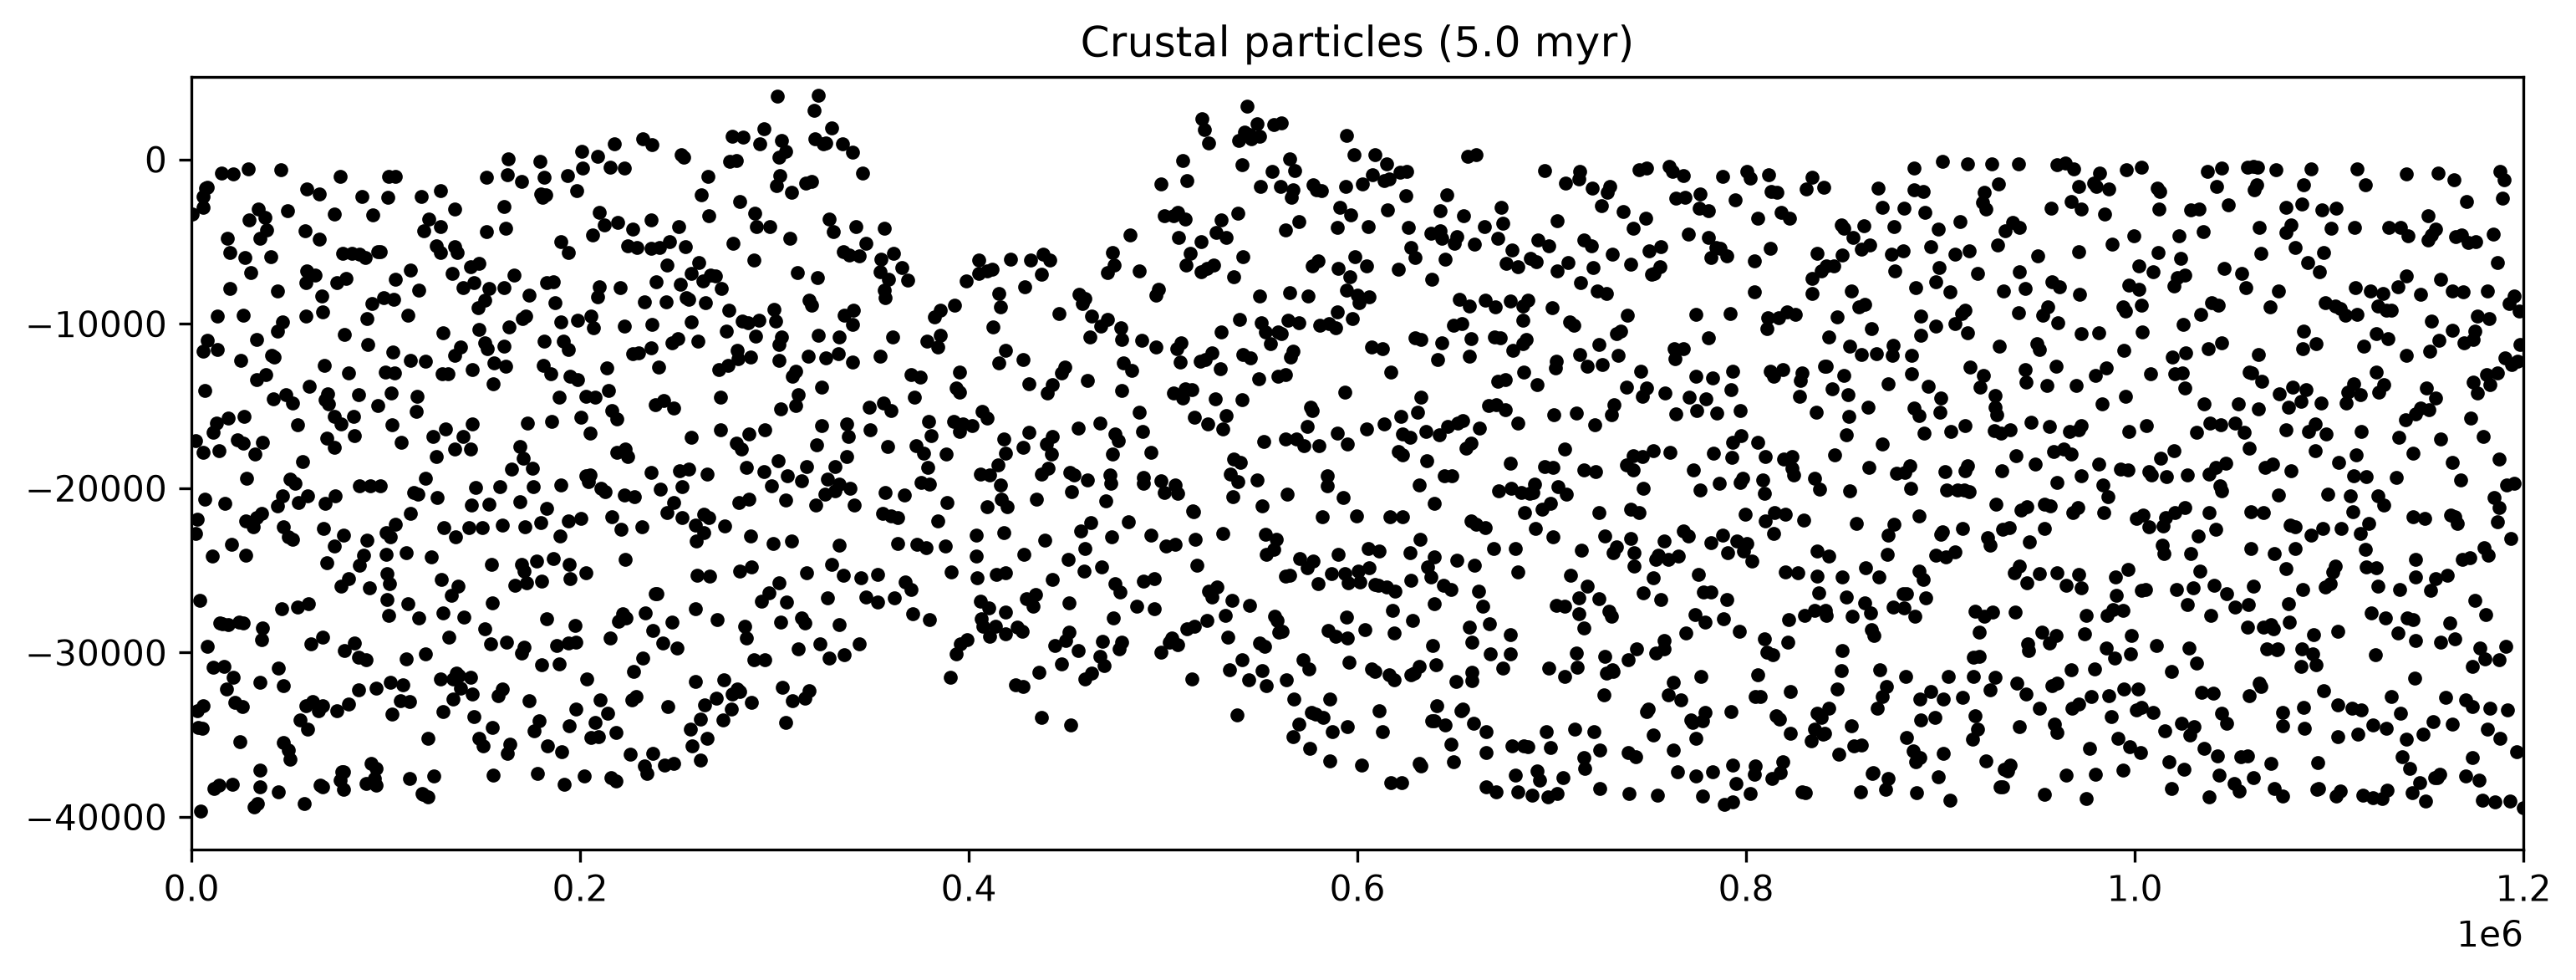

In [17]:
crust_t = crust_particles.sel(time=5, method='nearest') #selecting the crust particles at 5 Myr to plot their positions

# plotting the crust particle positions at 5 Myr through the matplotlib functions
plt.figure(figsize=(12,4),dpi=300)
plt.plot(crust_t.x, crust_t.z, marker='.',linestyle='None', color='black')
plt.xlim(0,1200e3); plt.ylim(-42e3,5e3)
plt.title(f"Crustal particles ({crust_t.time.values} myr)")

Text(0.5, 1.0, 'Crustal-Central particles (5.0 myr)')

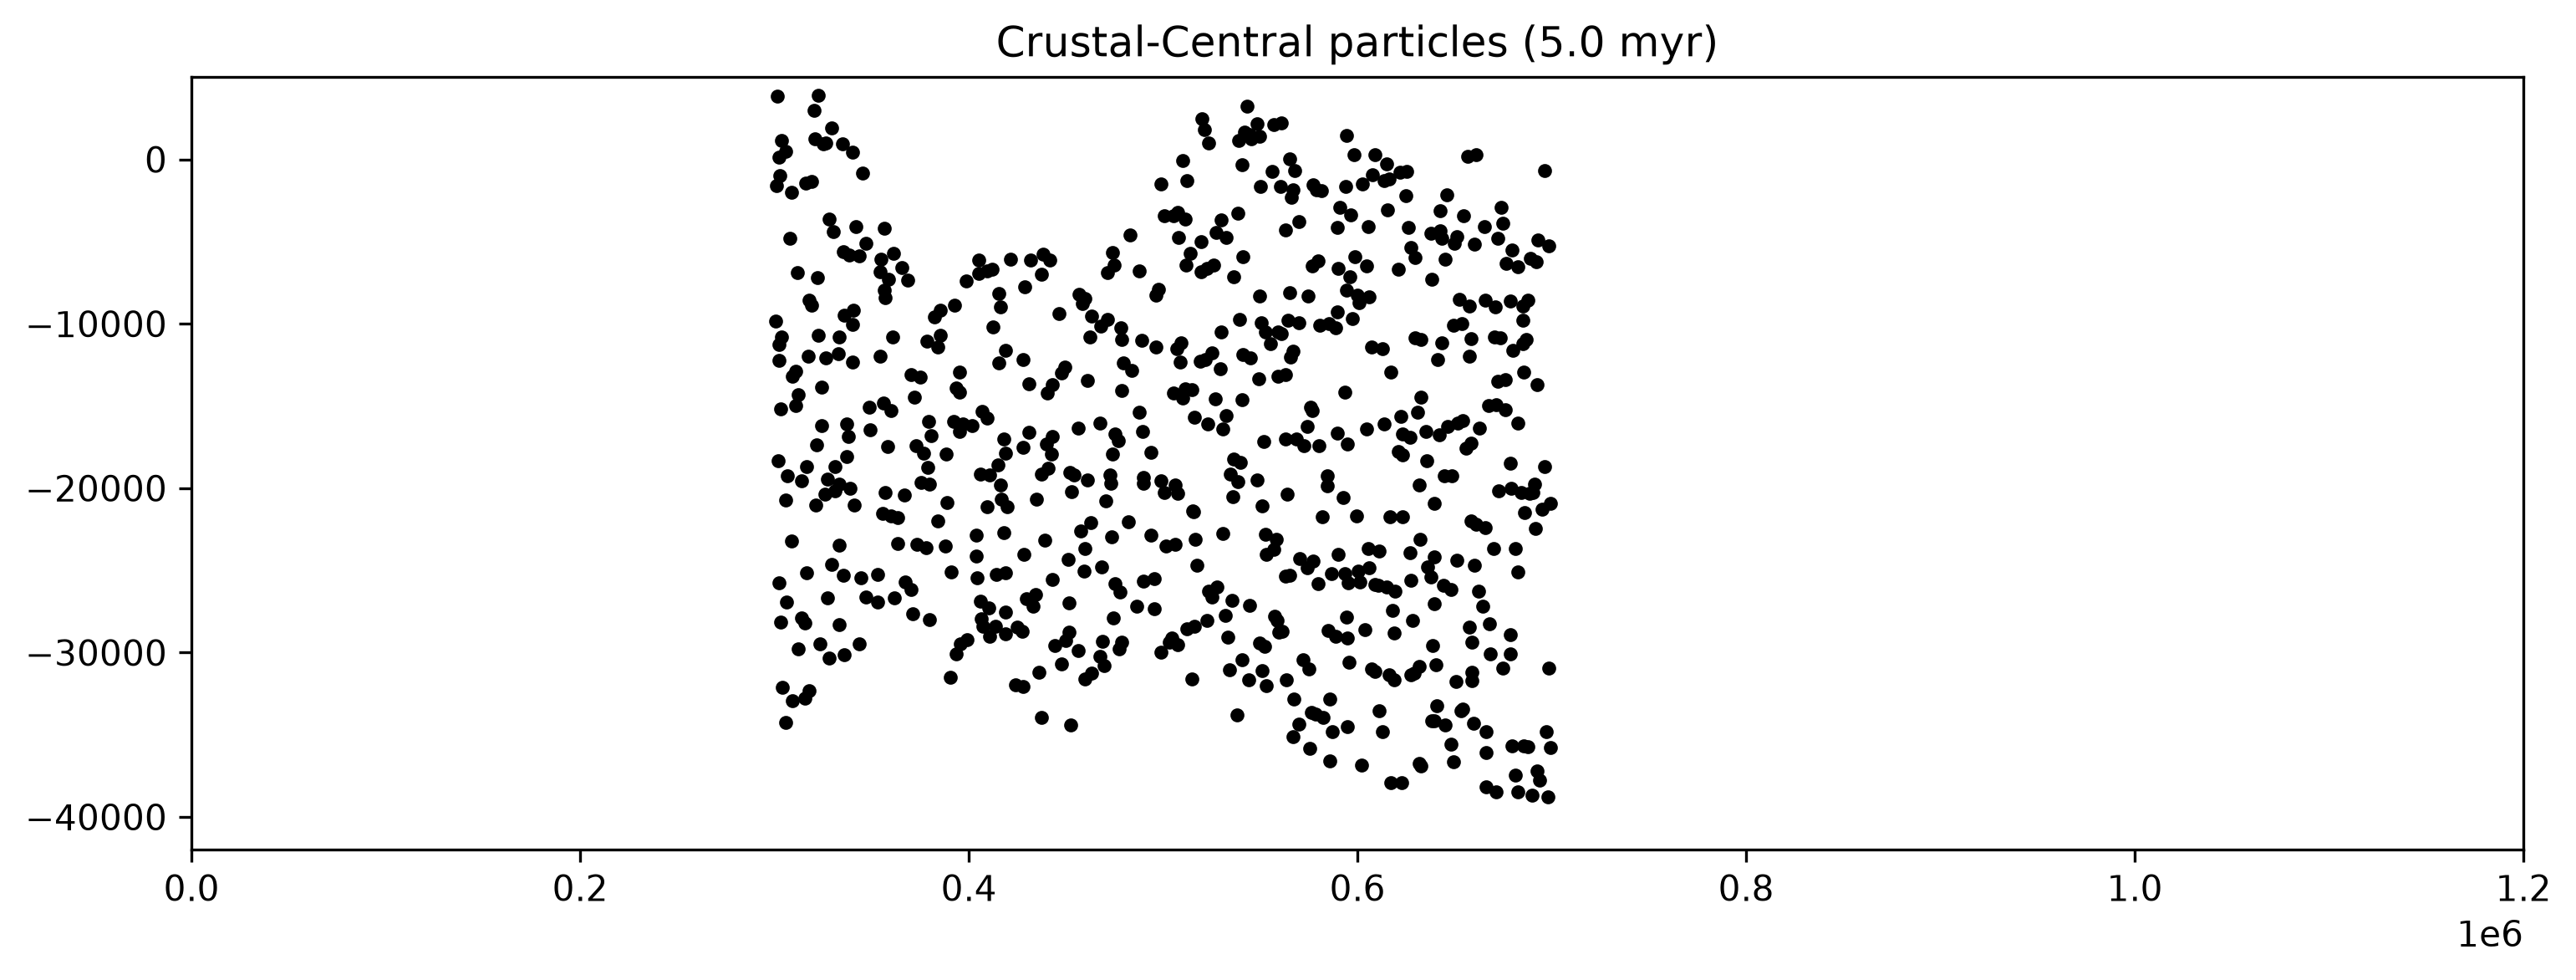

In [18]:
central_particles_t = central_particles.sel(time=5, method='nearest') #selecting the crust particles at 5 Myr to plot their positions

# plotting the crust particle positions at 5 Myr through the matplotlib functions
plt.figure(figsize=(12,4),dpi=300)
plt.plot(central_particles_t.x, central_particles_t.z, marker='.',linestyle='None', color='black')
plt.xlim(0,1200e3); plt.ylim(-42e3,5e3)
plt.title(f"Crustal-Central particles ({central_particles_t.time.values} myr)")

### A "fully" plot using the upscaled lithology tracked

Matplotlib has a good API and it is recommended for a fully customisable plot. A ```MandyocPlotter``` will be developed in future versions. 

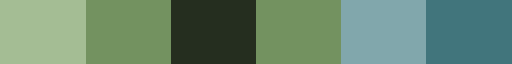

In [19]:
# Setting a colormap for the lithology
from matplotlib.colors import ListedColormap

# Creating a discrete colormap

# RGB (white shades)
colors_array = np.array([[0.76078431, 0.75294118, 0.75294118, 1.], # ast
                         [0.69294223, 0.68287476, 0.68287476, 1.], # lm
                         [0.69294223, 0.68287476, 0.68287476, 1.], # ws
                         [0.69294223, 0.68287476, 0.68287476, 1.], # lm
                         [0.62510015, 0.61280835, 0.61280835, 1.], # lc
                         [0.55725806, 0.54274194, 0.54274194, 1.], # uc
                                        ]) 

# Hexadecimal
colors_array = ["#A4BD94",  # ast 
                "#739260",  # lm
                "#252E1F",  # ws
                "#739260",  # lm
                "#81A7AC",  # lc
                "#41757C"]  # uc

colors_litho = ListedColormap(colors_array, name='litho',over='white',under='black')
display(colors_litho)

/home/jobueno/miniconda3/envs/tapioca/lib/python3.14/site-packages/dask/_task_spec.py:768: RuntimeWarning: divide by zero encountered in log10
  return self.func(*new_argspec)


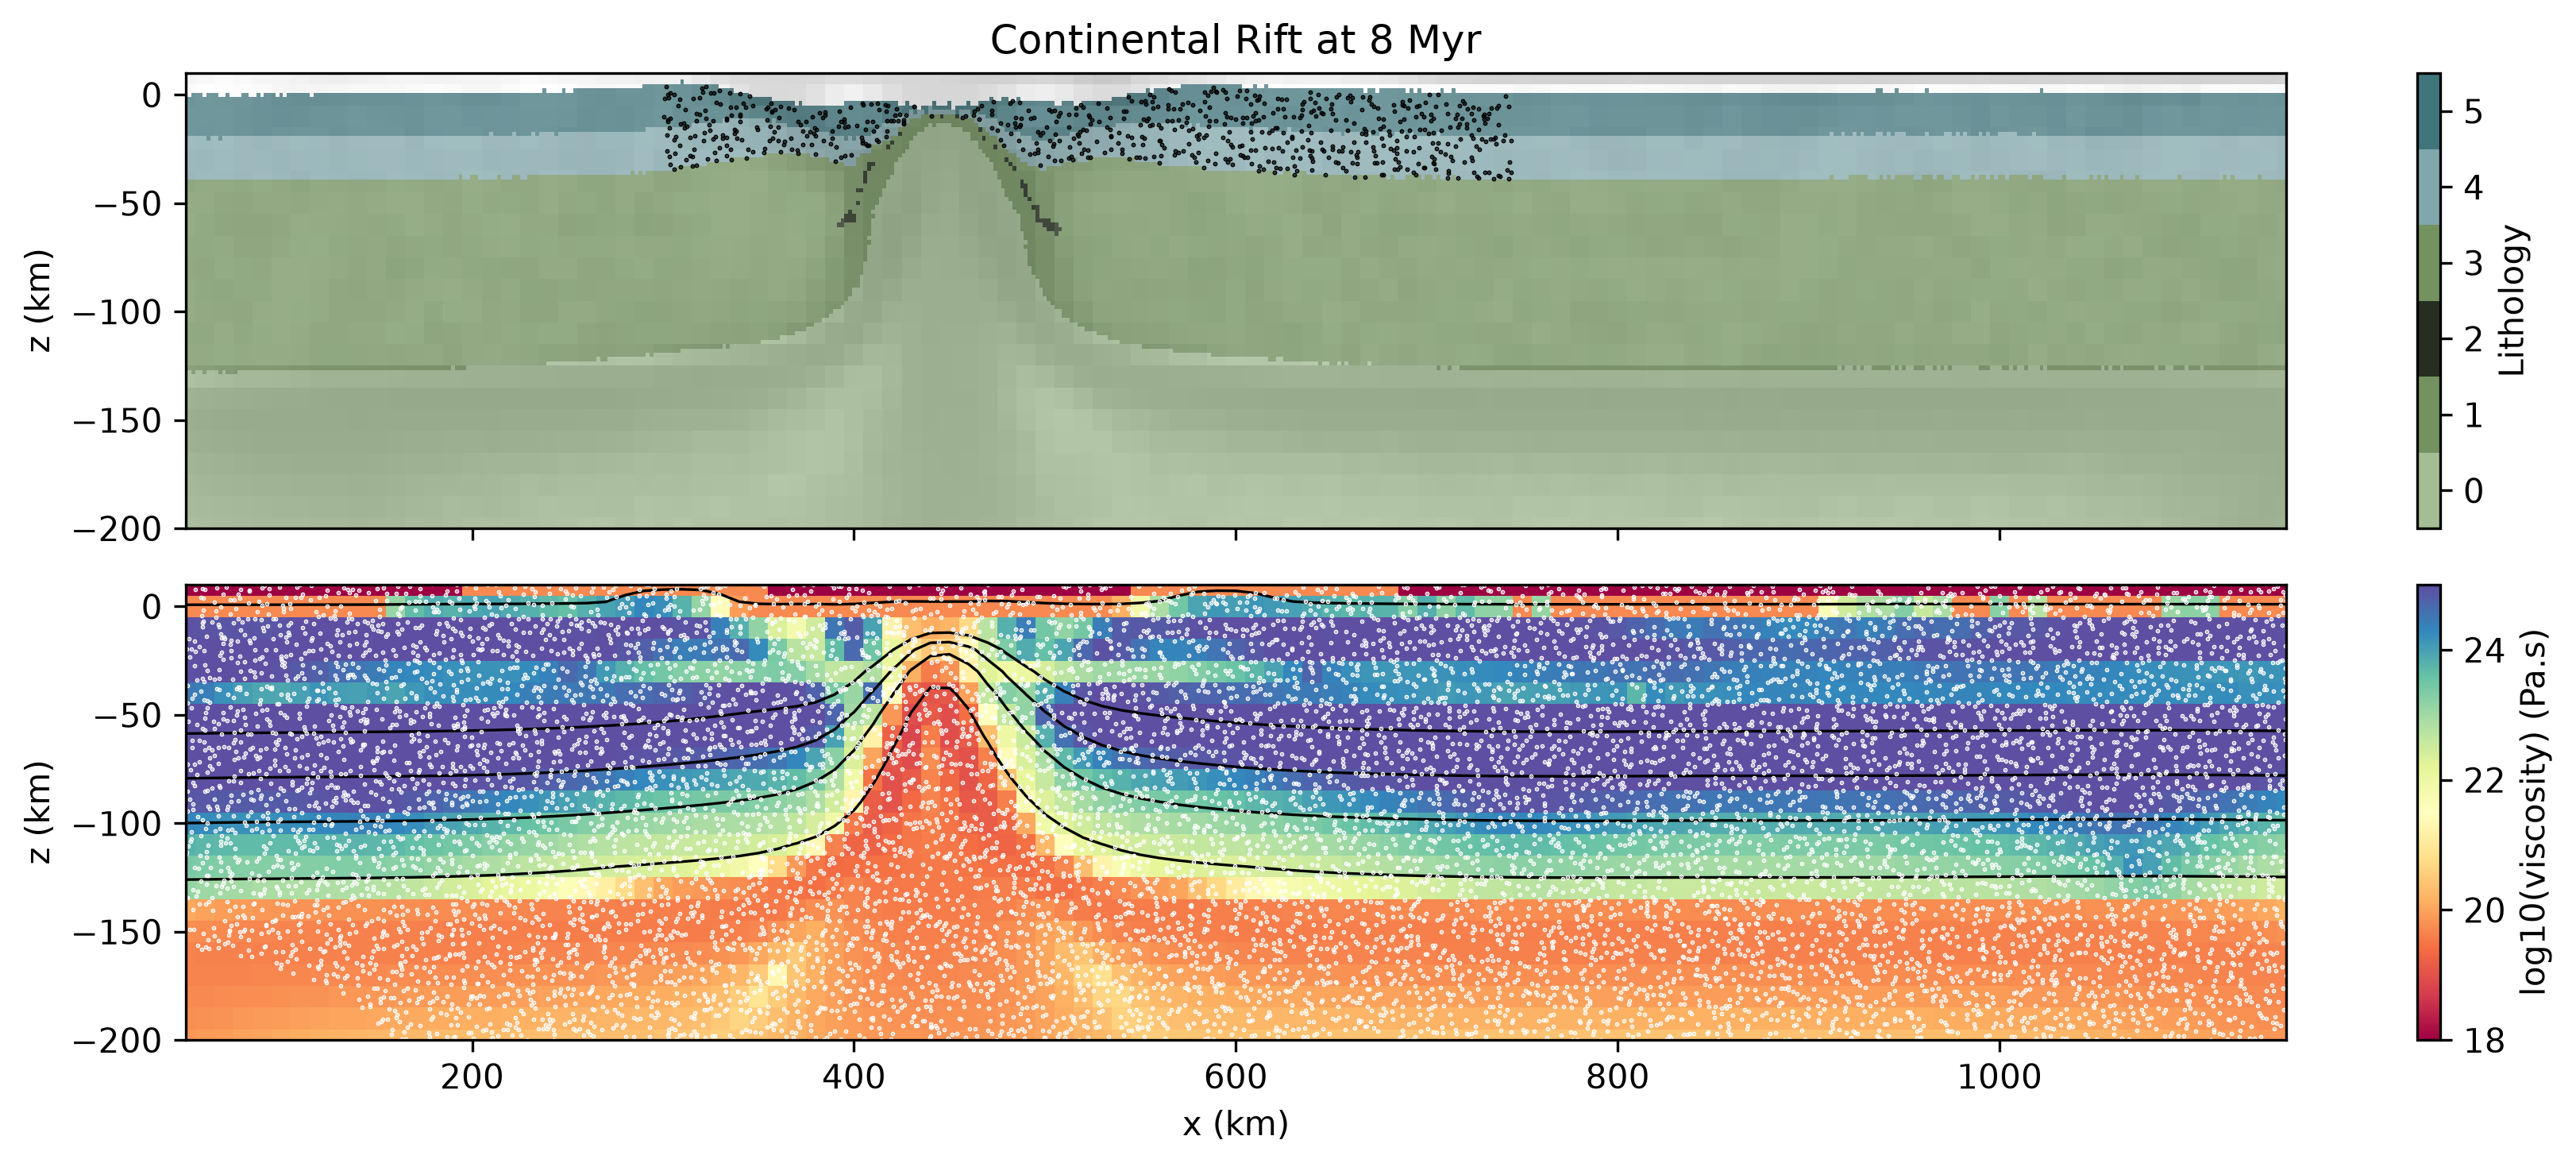

In [20]:
CRTsel = scen.DTree.sel(time=8,method='nearest') #Selecting the all data at 8 Myr
km = 1/1e3 # conversion factor to km for plotting

# Auxiliary variables to simplify the plotting code below
mesh = CRTsel.mesh['original'].ds
litho = CRTsel.mesh['upscaled'].ds
particles = CRTsel.particles['original'].ds
central = CRTsel.particles['central'].ds

# Figure with 2 axes
fig, axs = plt.subplots(2,1,figsize=(12,5),dpi=300, sharex=True, sharey=True)
ax_1, ax_2 = axs

# Axes 1: Lithology, strain, and central particles
litho_plot = ax_1.pcolormesh(litho.x*km,litho.z*km, litho['lithology'], cmap=colors_litho,vmin=-0.5,vmax=5.5)
ax_1.pcolormesh(mesh.x*km,mesh.z*km, np.log10(mesh['strain']), cmap='Grays', vmin=-1, vmax=1, alpha=0.25)
ax_1.plot(central.x*km, central.z*km, marker='.',linestyle='None', color='black', markersize=0.8)

# Axes 2: Viscosity, temperature contours, and all particles
visc_plot = ax_2.pcolormesh(mesh.x*km,mesh.z*km, np.log10(mesh['viscosity']), cmap='Spectral',vmin=18,vmax=25)
ax_2.contour(mesh.x*km,mesh.z*km, mesh['temperature'], colors='black', levels=[0,100,600,800,1000,1200,1350],linewidths=0.8)
ax_2.plot(particles.x*km, particles.z*km, marker='.',linestyle='None', color='white', markersize=0.7)

# Minor customisations:
plt.colorbar(litho_plot, ax=ax_1, label='Lithology')
plt.colorbar(visc_plot, ax=ax_2, label='log10(viscosity) (Pa.s)')

ax_1.set_xlim(50,1150)
ax_1.set_ylim(-200,10)

ax_1.set_title('Continental Rift at 8 Myr')
ax_1.set_ylabel('z (km)')
ax_2.set_xlabel('x (km)')
ax_2.set_ylabel('z (km)')

fig.tight_layout()
plt.show()